## **Name:** Nico Montoya

## **Computing ID:** zzm5rx

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score

# Lab 4: Unsupervised Learning on Tweets (100 Points)

## **Due December 1st, 2025 at 11:59PM EST**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1vbCuijewyF49JTfa0t1u0qBRypS_qF8N?usp=sharing)

You are a junior data scientist at **Bwitter Incorporated**, a massive social media platform that maintains a portfolio of millions of users internationally. Approximately 11 days ago, Bwitter recieved massive influx of traffic that many users and company leaders are now attributing to a [**bot attack**](https://en.wikipedia.org/wiki/Social_bot).

Your boss, Jim Ryan, has asked you to implement 2 models in the unsupervised learning family, **K-means clustering** and **Principal Component Analysis (PCA)**, on a subset of social media users on your platform to identify likely bots.

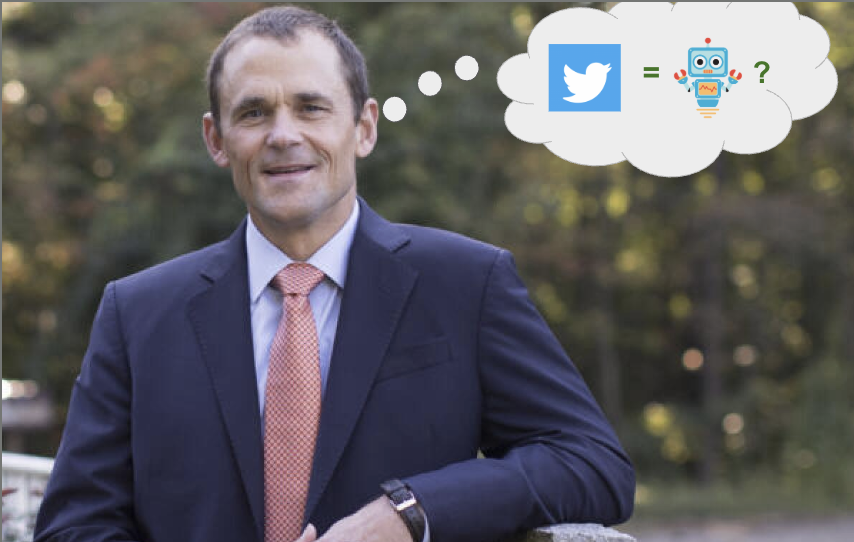

You will utilize the skills you have gained over the semester to build, explore, and evaluate your models. As always, you will be graded on your model building and interpretation of  results rather than specific performance. However, there is an optional extra credit opportunity if you wish to extend the unsupervised models you have applied.

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/0*h-lAg5H-ZNDRXxX2.png)

# **Real World Context**

Bot detection is a common unstructured text task. The dataset in this lab is derived from thousands of real tweets scraped in the 2010s with the Twitter API. Of the features provided, some notable ones include:


* **Tweet_text:** A difficult to encode raw text column with the original content of the tweet. It includes unicode, special characters, and sometimes non-english.
* **Count Columns:** Columns that has extracted the word, adverb, verb, noun, pronoun, punctuation, and special characters in the tweet body.
* **Sentiment Columns:** Columns that mention word ratios that are positive, negative, or ratio from the tweet body.
* **Followers and Following:** Columns that compute the amount of accounts a user has as followers or a user is following respectively.
* **Location:** Self-provided location string that may be a real location or not.
* **Real_Location:** 1 if Location seems plausible, 0 if not, -1 if missing.
* **Bot or Not:** A column hidden from you that contained a Twitter given label of a social media bot. This column is filled with NaNs when you read the CSV in to prevent you from seeing the true label of a tweet.


Interestingly, **only about 15% of this data is identified as bots**. Although the target feature is hidden from you, you now have many starting points for an unsupervised model analysis!

### To guide your analysis, also review the graphic below which summarizes the data using the Bot or Not label. As expected, bots often have extreme maximum ranges of values even when their means do not differ notably from human accounts. **You do not have access to the Bot or Not label in this lab. However, you can use the graphic below to explain and justify your results!**
### Less obvious bots might present themselves in normal ranges of these features - think about how might you use unsupervised learning to help differentiate humans and botnets.

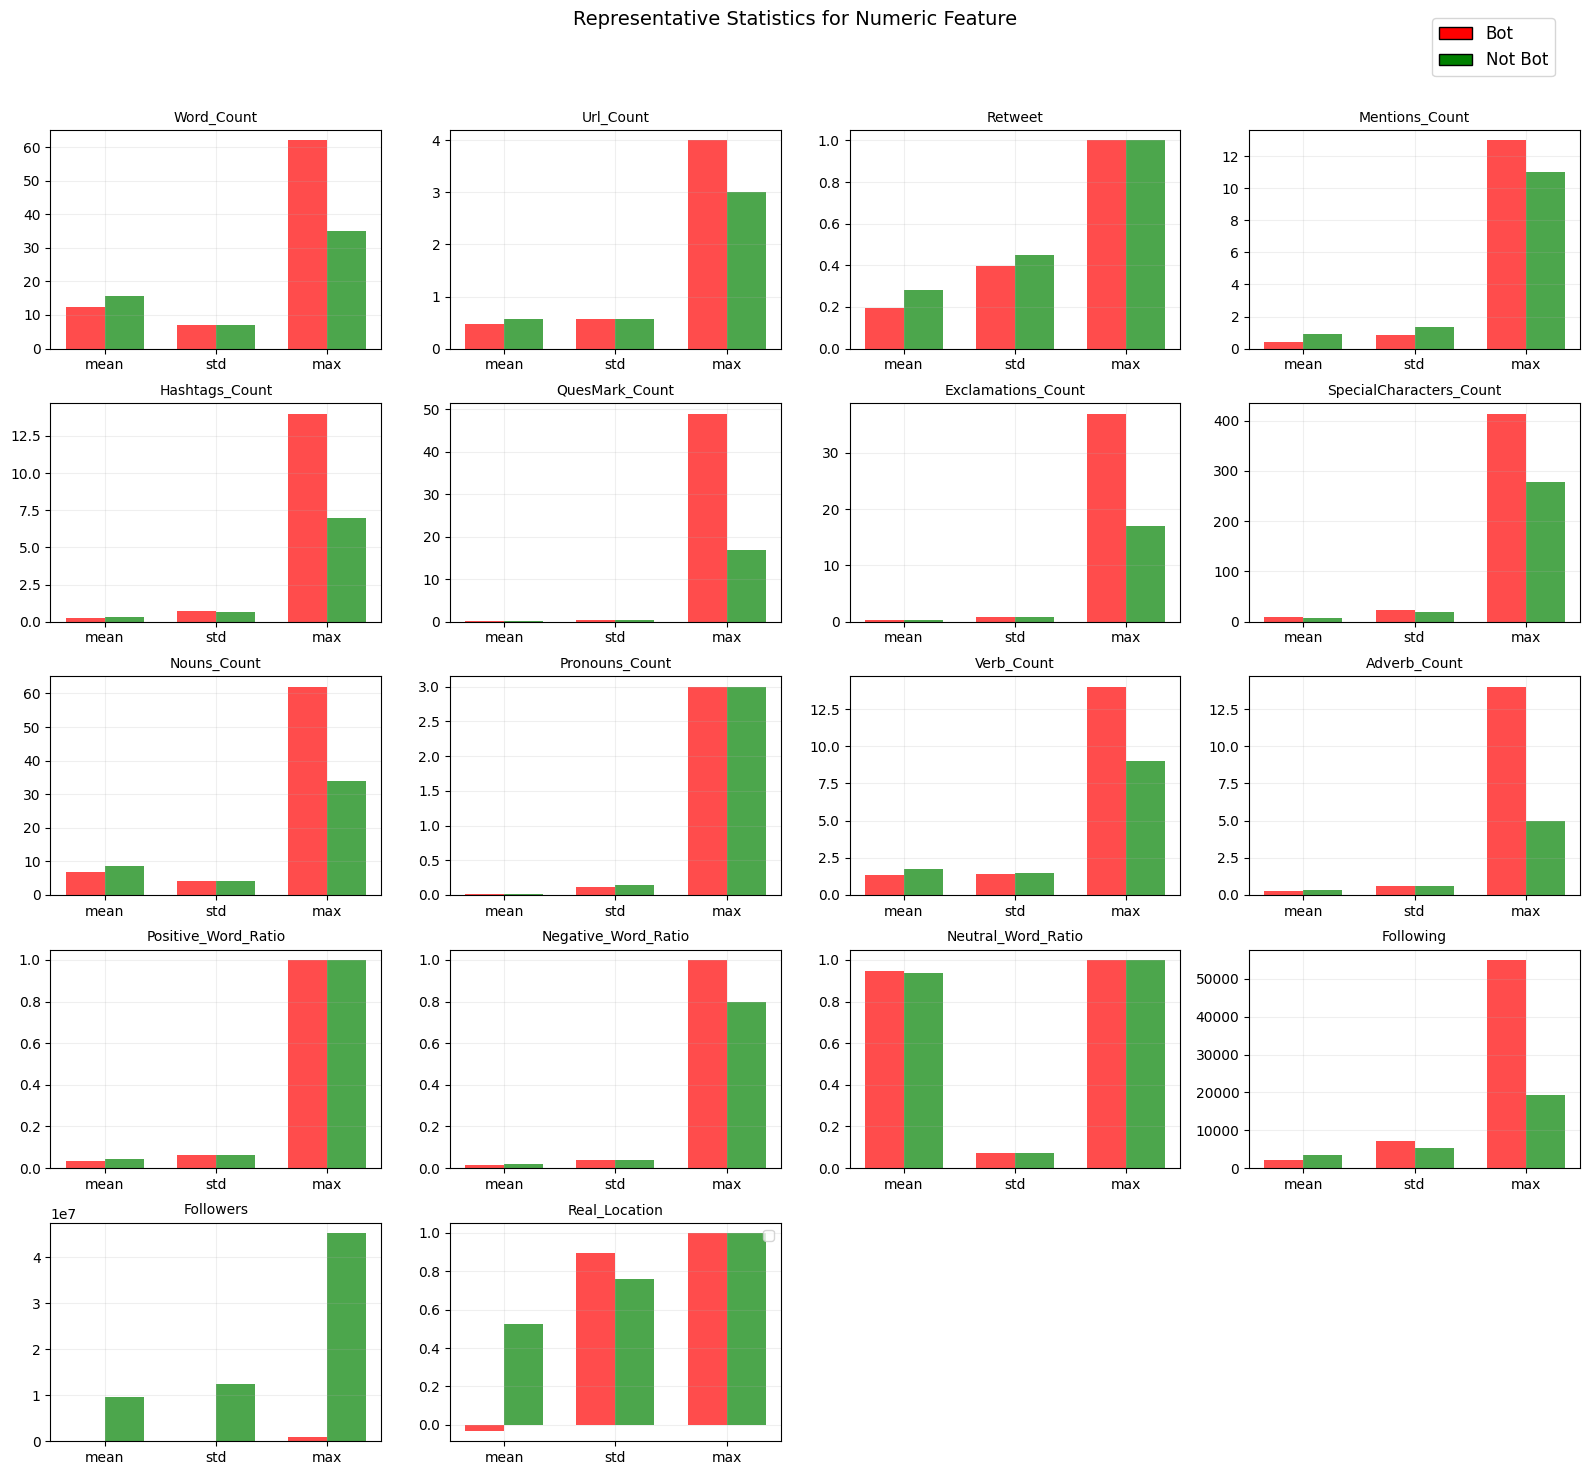

# **Part 1: EDA and Data Cleaning (10 points)**

Load in the provided CSV "Tweets.csv" and observe the columns below. The original binary target column "Bot Or Not" **has been removed** and now only contains NaNs.

In [2]:
df_raw = pd.read_csv("clean_tweets.csv")
df_raw = df_raw.sample(frac=1, random_state=3001)
df = df_raw

In [3]:
df.head()

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Verb_Count,Adverb_Count,Positive_Word_Ratio,Negative_Word_Ratio,Neutral_Word_Ratio,Following,Followers,Location,Real_Location,bot_or_not
222015,1.042100e+18,18-09-2018 17:08,James Wong,Botanygeek,British-Malaysian botanist with a special inte...,@yungcav @contrarybass Nope. Not true. It\xe2\...,16,0,0,2,...,1,2,0.045455,0.000000,0.954545,3882,179800,NaN,-1.0,NaN
238438,1.062740e+18,14-11-2018 16:16,Newfound Planets,I_Find_Planets,What distant worlds may be like. Or not. I'll ...,You have discovered a planet. It is peach. It ...,21,0,0,0,...,4,0,0.037037,0.037037,0.925926,183,9998,Out there in the Cosmos,0.0,NaN
13306,1.049800e+17,20-08-2011 18:17,Jesus Cristo,itsJesusCristo,"Eu sou o caminho, e a verdade e a vida. Não se...",Eu te ressuscito! RT @macarena_rs: ''quer mais...,15,0,0,0,...,0,0,0.000000,0.000000,1.000000,3,1086,Ceu do Twitter,0.0,NaN
102937,8.314880e+17,14-02-2017 13:01,Kris Anderson,KrisAndersonTV,Father of three amazing sons & loving husband....,@SibilioW @cdelcampon7 @7News thanks Bob,5,0,0,3,...,1,0,0.125000,0.000000,0.875000,20500,30100,Florida,1.0,NaN
26855,9.380940e+17,05-12-2017 17:11,Sarah Nagem,sarah_nagem,Assistant metro editor at The News & Observer....,@jonmalexander @Blovee_20 Here it is: https://...,6,1,0,2,...,0,0,0.000000,0.000000,1.000000,1314,1571,Raleigh,1.0,NaN


Many rows in the dataset are clearly bots. Let's filter rows that contain "bot" in the usename or account.

In [4]:
df[df['Twitter_Account'].str.contains("bot")].head(5)

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Verb_Count,Adverb_Count,Positive_Word_Ratio,Negative_Word_Ratio,Neutral_Word_Ratio,Following,Followers,Location,Real_Location,bot_or_not
8260,9.108540e+17,21-09-2017 13:13,Robots Rule,RobotzRule,"I love robots, and I retweet stories about the...",RT @TRADOC: The #USArmy is developing robot re...,14,2,1,1,...,2,0,0.0,0.000,1.000,24,2198,The Internetz,0.0,NaN
109012,1.000340e+18,26-05-2018 11:43,Quilt Bot,a_quilt_bot,Tweet pictures at me and I'll try to reproduce...,@CommonsBot https://t.co/HMh1r3JheV,2,1,0,1,...,0,0,0.0,0.000,1.000,2,2828,Swatchspace,0.0,NaN
187262,1.068940e+18,01-12-2018 18:31,Hacker News Bot,hackernewsbot,Tweeting the hottest from Hacker News (YC),Psychology\xe2\x80\x99s Replication Crisis Is ...,6,1,0,0,...,0,0,0.0,0.125,0.875,0,23700,Internetz,0.0,NaN
72965,7.435730e+17,16-06-2016 22:36,portmanteau_bot,portmanteau_bot,"portmanteaus, portmanteaus everywhere // by @t...",outrightness,1,0,0,0,...,0,0,0.0,0.000,1.000,0,1960,NaN,-1.0,NaN
152876,2.743770e+17,30-11-2012 05:00,Beckett Bot,beckettbot,by @dontsave,RT @Syafa_Queen: I will go on..,6,0,1,0,...,1,0,0.0,0.000,1.000,0,79,NaN,-1.0,NaN


In [5]:
# A few likely bot messages
df[df['Twitter_Account'].str.contains("bot")]["Tweet_text"].tolist()[0:5]

['RT @TRADOC: The #USArmy is developing robot resupply vehicles https://t.co/3KQMcePMep via @ArmyTimes #MultiDomainBattle https://t.co/lMZ639\\xe2\\x80\\xa6',
 '@CommonsBot https://t.co/HMh1r3JheV',
 'Psychology\\xe2\\x80\\x99s Replication Crisis Is Real https://t.co/Pi7RlWKezU',
 'outrightness',
 'RT @Syafa_Queen: I will go on..']

## **Question 1 (10 points):**
## Unstructured text columns may prove hard to preprocess for unsupervised learning and need standardizing. Run the following data cleaning steps in order to ensure you can still extract information from unstructured text:

## **These steps have been completed for you! You only need to run the cell and focus on understanding the code provided.**

### **1. Standardizing text usually implies lowercasing it. Run this cell to lowercase your text columns: Twitter_User_Name, Twitter_Account, Twitter_User_Description, Tweet_id, Tweet_text, and Location**

In [6]:
lower_cols = ['Twitter_User_Name',
    'Twitter_Account',
    'Twitter_User_Description',
    'Tweet_id',
    'Tweet_text',
    'Location']

for col in lower_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower()
df.head(3)

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Verb_Count,Adverb_Count,Positive_Word_Ratio,Negative_Word_Ratio,Neutral_Word_Ratio,Following,Followers,Location,Real_Location,bot_or_not
222015,1.0421e+18,18-09-2018 17:08,james wong,botanygeek,british-malaysian botanist with a special inte...,@yungcav @contrarybass nope. not true. it\xe2\...,16,0,0,2,...,1,2,0.045455,0.000000,0.954545,3882,179800,nan,-1.0,NaN
238438,1.06274e+18,14-11-2018 16:16,newfound planets,i_find_planets,what distant worlds may be like. or not. i'll ...,you have discovered a planet. it is peach. it ...,21,0,0,0,...,4,0,0.037037,0.037037,0.925926,183,9998,out there in the cosmos,0.0,NaN
13306,1.0498e+17,20-08-2011 18:17,jesus cristo,itsjesuscristo,"eu sou o caminho, e a verdade e a vida. não se...",eu te ressuscito! rt @macarena_rs: ''quer mais...,15,0,0,0,...,0,0,0.000000,0.000000,1.000000,3,1086,ceu do twitter,0.0,NaN


### **2.  Many people create bots on Twitter for helpful reasons. They usually create usernames with the word "bot" in them like you saw above.**

### **Run this cell to make a new column called "mentions_bot" that is 1 if 'bot' is mentioned in the Twitter_User_Name OR Twitter_Account columns.**

### **While there may be some false positives (ie: botany), this will be a very helpful column to use as a reference for unsupervised learning.**

In [7]:
df['mentions_bot'] = (df['Twitter_User_Name'].str.contains("bot", na=False) | df['Twitter_Account'].str.contains("bot", na=False)).astype(int)
df.head(3)

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Adverb_Count,Positive_Word_Ratio,Negative_Word_Ratio,Neutral_Word_Ratio,Following,Followers,Location,Real_Location,bot_or_not,mentions_bot
222015,1.0421e+18,18-09-2018 17:08,james wong,botanygeek,british-malaysian botanist with a special inte...,@yungcav @contrarybass nope. not true. it\xe2\...,16,0,0,2,...,2,0.045455,0.000000,0.954545,3882,179800,nan,-1.0,NaN,1
238438,1.06274e+18,14-11-2018 16:16,newfound planets,i_find_planets,what distant worlds may be like. or not. i'll ...,you have discovered a planet. it is peach. it ...,21,0,0,0,...,0,0.037037,0.037037,0.925926,183,9998,out there in the cosmos,0.0,NaN,0
13306,1.0498e+17,20-08-2011 18:17,jesus cristo,itsjesuscristo,"eu sou o caminho, e a verdade e a vida. não se...",eu te ressuscito! rt @macarena_rs: ''quer mais...,15,0,0,0,...,0,0.000000,0.000000,1.000000,3,1086,ceu do twitter,0.0,NaN,0


### **3. Run this cell to label encode the Twitter_User_Name and Twitter_Account columns.**

In [8]:
le_user = LabelEncoder()
le_account = LabelEncoder()

df['Twitter_User_Name_encoded'] = le_user.fit_transform(df['Twitter_User_Name'].astype(str))
df['Twitter_Account_encoded']   = le_account.fit_transform(df['Twitter_Account'].astype(str))
df.head(3)

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Negative_Word_Ratio,Neutral_Word_Ratio,Following,Followers,Location,Real_Location,bot_or_not,mentions_bot,Twitter_User_Name_encoded,Twitter_Account_encoded
222015,1.0421e+18,18-09-2018 17:08,james wong,botanygeek,british-malaysian botanist with a special inte...,@yungcav @contrarybass nope. not true. it\xe2\...,16,0,0,2,...,0.000000,0.954545,3882,179800,nan,-1.0,NaN,1,40,18
238438,1.06274e+18,14-11-2018 16:16,newfound planets,i_find_planets,what distant worlds may be like. or not. i'll ...,you have discovered a planet. it is peach. it ...,21,0,0,0,...,0.037037,0.925926,183,9998,out there in the cosmos,0.0,NaN,0,64,36
13306,1.0498e+17,20-08-2011 18:17,jesus cristo,itsjesuscristo,"eu sou o caminho, e a verdade e a vida. não se...",eu te ressuscito! rt @macarena_rs: ''quer mais...,15,0,0,0,...,0.000000,1.000000,3,1086,ceu do twitter,0.0,NaN,0,46,38


### **4. Run this cell to cast Tweet_id as an integer column.**

In [9]:
df['Tweet_id'] = pd.to_numeric(df['Tweet_id'], errors='coerce').astype("Int64")
df.head(3)

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Negative_Word_Ratio,Neutral_Word_Ratio,Following,Followers,Location,Real_Location,bot_or_not,mentions_bot,Twitter_User_Name_encoded,Twitter_Account_encoded
222015,1042100000000000000,18-09-2018 17:08,james wong,botanygeek,british-malaysian botanist with a special inte...,@yungcav @contrarybass nope. not true. it\xe2\...,16,0,0,2,...,0.000000,0.954545,3882,179800,nan,-1.0,NaN,1,40,18
238438,1062740000000000000,14-11-2018 16:16,newfound planets,i_find_planets,what distant worlds may be like. or not. i'll ...,you have discovered a planet. it is peach. it ...,21,0,0,0,...,0.037037,0.925926,183,9998,out there in the cosmos,0.0,NaN,0,64,36
13306,104980000000000000,20-08-2011 18:17,jesus cristo,itsjesuscristo,"eu sou o caminho, e a verdade e a vida. não se...",eu te ressuscito! rt @macarena_rs: ''quer mais...,15,0,0,0,...,0.000000,1.000000,3,1086,ceu do twitter,0.0,NaN,0,46,38


### **5. Bots tend to follow more accounts than they have followers. Take a look at the visual below to understand if this is true for your data.**

###**Then, run the code below to add a column for the ratio of followers to following.**

Visual on median following ratios:

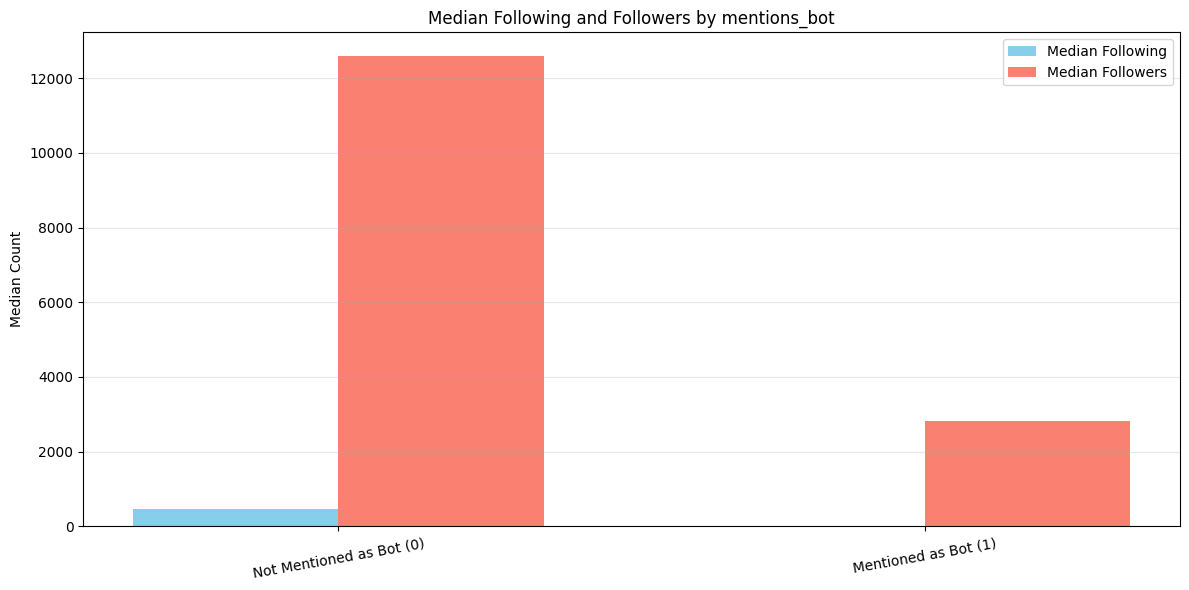

In [10]:
# Add ratio column
df['followers_following_ratio'] = df['Followers'] / (df['Following'] + 1)
df.head(3)

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Neutral_Word_Ratio,Following,Followers,Location,Real_Location,bot_or_not,mentions_bot,Twitter_User_Name_encoded,Twitter_Account_encoded,followers_following_ratio
222015,1042100000000000000,18-09-2018 17:08,james wong,botanygeek,british-malaysian botanist with a special inte...,@yungcav @contrarybass nope. not true. it\xe2\...,16,0,0,2,...,0.954545,3882,179800,nan,-1.0,NaN,1,40,18,46.304404
238438,1062740000000000000,14-11-2018 16:16,newfound planets,i_find_planets,what distant worlds may be like. or not. i'll ...,you have discovered a planet. it is peach. it ...,21,0,0,0,...,0.925926,183,9998,out there in the cosmos,0.0,NaN,0,64,36,54.336957
13306,104980000000000000,20-08-2011 18:17,jesus cristo,itsjesuscristo,"eu sou o caminho, e a verdade e a vida. não se...",eu te ressuscito! rt @macarena_rs: ''quer mais...,15,0,0,0,...,1.000000,3,1086,ceu do twitter,0.0,NaN,0,46,38,271.500000


### **5. Finally, Tweet_created_at is a string date which can be difficult to encode. Data scientists often convert dates into seconds because they are easier to process.**

### **Run the code below to**
### (1) Convert Tweet_created_at from a string to a datetime type  

### (2) Convert datetime to seconds, which is an **integer**

### Epoch time is very frequently used to convert date objects into a parseable format for modelling!

Reference: https://en.wikipedia.org/wiki/Unix_time

In [11]:
df['Tweet_created_at'] = pd.to_datetime(df['Tweet_created_at'], errors='coerce')
df['Tweet_created_at_epoch'] = df['Tweet_created_at'].astype('int64') // 10**9

/tmp/ipython-input-1879415004.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Tweet_created_at'] = pd.to_datetime(df['Tweet_created_at'], errors='coerce')


### **6. Run the cell below to drop the original unecoded columns and text columns. This cell will also standardize the remaining features.**

In [12]:
df = df.drop(columns=["Twitter_User_Description", "Location", "Tweet_text",
                      "Twitter_User_Name", "Twitter_Account", "Tweet_created_at",
                      "Following", "Followers", "bot_or_not"], errors='ignore')

In [13]:
X = df.select_dtypes(include='number').copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Your preprocessing is complete! You will use X_scaled as your input data for your unsupervised models.**

In [14]:
X_scaled

array([[ 0.91570737,  0.42924789, -0.87207354, ..., -1.00625431,
        -0.12780017,  0.9154831 ],
       [ 0.99114844,  1.12094737, -0.87207354, ..., -0.2961261 ,
        -0.12779647,  0.99090705],
       [-2.50955078,  0.29090799, -0.87207354, ..., -0.21722297,
        -0.12769637, -2.50848789],
       ...,
       [ 0.61332907, -1.50751065,  0.89414418, ...,  0.72961464,
        -0.1274083 ,  0.61322368],
       [ 0.88716112,  0.98260747, -0.87207354, ..., -0.2961261 ,
        -0.12779647,  0.88696695],
       [ 0.3934425 ,  0.84426758,  0.89414418, ...,  1.00577561,
        -0.12778099,  0.39341955]])

# **Part 2: K-Means Clustering (10 points)**

## **Question 1 (5 points):**
## Run the cell below to build an elbow diagnostic below for k=1 to 50 clusters. This may take a while to run but builds character as a data scientist. Write the optimal k in a text cell.

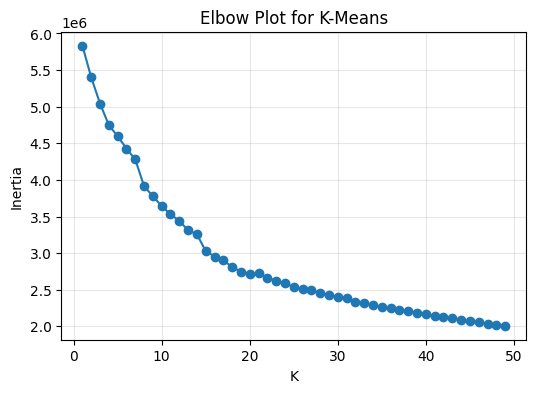

In [15]:
inertia = []
K = range(1, 50)

for k in K:
    km = KMeans(n_clusters=k, random_state=3001)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Plot for K-Means")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

**The optimal k is 8 because the curve shows an elbow around k=8 which is where additional clusters begin to lead diminishing returns.**

## **Question 2 (5 points):**

## Run the cells below to create a K-Means Clustering model with your optimal.

## Then, run the remaining cell to print your cluster sizes and add your cluster assignments to your DataFrame.

In [16]:
k = 8 # Change me!

kmeans = KMeans(n_clusters=k, random_state=3001)
labels = kmeans.fit_predict(X_scaled)

In [17]:
df['cluster'] = labels
print("Cluster sizes:")
print(df['cluster'].value_counts())

Cluster sizes:
cluster
1    49075
2    49020
4    48081
7    45012
6    42681
0    23390
3     4622
5     3244
Name: count, dtype: int64


# **Part 3: Principal Component Analysis (20 Points)**

## **Question 1 (10 points):**
## Display any PCA diagnostic that allows you to determine the minimum number components to explain 95% cumulative variance in **X_scaled**. An example visual is shown that you may want to replicate.

## Write the minimum number components in a text cell.

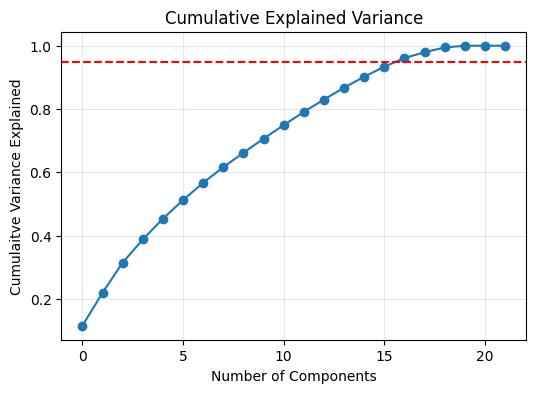

In [18]:
# Diagnostic plot here
pca = PCA()
pca.fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_
                    )
plt.figure(figsize = (6,4))
plt.plot(cum_var,marker ='o')
plt.axhline(y=0.95, color = 'red', linestyle = '--')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulaitve Variance Explained")
plt.grid(alpha =0.3)
plt.show()

**The minimum number is 16 as that is the number of components that is takes to meet the 0.95 threshold.**

## **Question 2 (10 points):**
## Run PCA with the minimum number components on **X_scaled**. Store your fit_transform object in a variable called **X_pca**. Then, run the cell below to extract the first 5 principal components and create columns for them in your DataFrame.

In [19]:
# PCA code
pca = PCA(n_components = 16)
X_pca = pca.fit_transform(X_scaled)

In [20]:
df['PC1'] = X_pca[:,0]
df['PC2'] = X_pca[:,1]
df['PC3'] = X_pca[:,2]
df['PC4'] = X_pca[:,3]
df['PC5'] = X_pca[:,4]

# **Part 4: Bot Detection (60 Points)**

## Your DataFrame now has columns for K-means cluster and PCs 1 through 5. The final part of the lab will involve visualizing your results and identifying likely bots based on the data you've extracted.

## While you don't have the ground truth label - you do have a column you created called **mentions_bot**! This column will be very useful in identifying any **remaining bots**. Think through the remaining interpretation steps intentionally.

In [21]:
df.head(5)

,Tweet_id,Word_Count,Url_Count,Retweet,Mentions_Count,Hashtags_Count,QuesMark_Count,Exclamations_Count,SpecialCharacters_Count,Nouns_Count,...,Twitter_User_Name_encoded,Twitter_Account_encoded,followers_following_ratio,Tweet_created_at_epoch,cluster,PC1,PC2,PC3,PC4,PC5
222015,1042100000000000000,16,0,0,2,0,0,0,9,7,...,40,18,46.304404,1537290480,2,0.216711,-0.251568,0.781141,-1.063458,1.642552
238438,1062740000000000000,21,0,0,0,0,0,0,6,4,...,64,36,54.336957,1542212160,2,0.873352,-0.697787,1.451404,-0.387741,1.287307
13306,104980000000000000,15,0,0,0,0,0,1,14,14,...,46,38,271.500000,1313864220,4,-0.791253,-0.497855,-3.495289,1.302151,-0.641385
102937,831488000000000000,5,0,0,3,0,0,0,3,5,...,51,49,1.468221,1487077260,0,-0.688323,-0.867387,0.933172,-0.824275,-2.154439
26855,938094000000000000,6,1,0,2,0,0,0,3,5,...,77,72,1.194677,1512493860,1,0.069513,2.100304,0.587610,-0.196531,-1.316315


## **Question 1 (10 points):**
## Run the below code to merge your cluster and PC data into the original data. This will create a new dataframe called plot_df.

In [22]:
# Unsupervised output
df_unsup = df[['Tweet_id', 'cluster', 'PC1','PC2','PC3','PC4','PC5']]
df_unsup['Tweet_id']  = df_unsup['Tweet_id'].astype(str)

# Merge data
df_original = pd.read_csv("clean_tweets.csv")
df_original['Tweet_id'] = pd.to_numeric(df_original['Tweet_id'], errors='coerce').astype("Int64")
df_original['mentions_bot'] = (df_original['Twitter_User_Name'].str.contains("bot", na=False) | df_original['Twitter_Account'].str.contains("bot", na=False)).astype(int)
df_original['Tweet_id'] = df_original['Tweet_id'].astype(str)

plot_df = df_original.merge(df_unsup, on='Tweet_id', how='left')
plot_df = plot_df.sample(frac=1, random_state=3001)
plot_df.head(5)

/tmp/ipython-input-654373317.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unsup['Tweet_id']  = df_unsup['Tweet_id'].astype(str)


,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Location,Real_Location,bot_or_not,mentions_bot,cluster,PC1,PC2,PC3,PC4,PC5
289489,1018690000000000000,16-07-2018 03:08,Darius Kazemi,tinysubversions,I make weird internet art. I've mostly left Tw...,103. https://t.co/KqpyuRQRCe,2,1,0,0,...,Scotland,1.0,NaN,0,6,-1.096452,1.406877,-0.208093,-2.809745,-0.506190
1302502,1042090000000000000,18-09-2018 16:37,Subrahmanyam KVJ,SuB8u,Technology | Science | Business | Media | Inte...,RT @geoffreyfowler: My favorite #iOS12 additio...,17,0,1,3,...,127.0.0.2,0.0,NaN,0,2,2.281224,1.248259,0.892084,0.652624,0.468444
1497551,1065270000000000000,21-11-2018 16:00,Security News Bot,SecurityNewsbot,Tweeting all things #InfoSec #Cybercrime #DDoS...,TrickBot\xe2\x80\x99s Bigger Bag of Tricks htt...,7,1,0,0,...,Internet,0.0,NaN,1,1,0.200733,1.850991,1.864467,1.436735,-0.258871
281135,405429000000000000,26-11-2013 20:13,LOUDBOT,LOUDBOT,I'LL JUST PUT THIS PLUTONIUM IN THE SINK,WE'RE NO STRANGERS TO LOVE YOU KNOW THAT,8,0,0,0,...,I'm from the internet,0.0,NaN,0,0,-2.134526,-3.438382,1.481524,2.638608,0.189666
1333768,1029400000000000000,14-08-2018 16:02,Andrew McMahon,andrewmcmahon,New album Upside Down Flowers ft. Ohio out now...,Pleased to announce the 9th annual @DearJackHQ...,21,1,0,1,...,Southern CA,1.0,NaN,0,3,3.410134,1.065824,-1.551110,-0.920275,0.171803


## Run the below code to randomly sample 10,000 points from your data for plotting. Because plot_df is very high dimensional, you will only want to plot a subset of the data at a time.

In [23]:
# Yikes!
plot_df.shape

(1832193, 33)

In [24]:
plot_df = plot_df.sample(n=min(10_000, len(plot_df)), random_state=3001)
plot_df.head(3)

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,Location,Real_Location,bot_or_not,mentions_bot,cluster,PC1,PC2,PC3,PC4,PC5
185421,533707000000000000,15-11-2014 19:45,Asad Umar,Asad_Umar,"Ex naukri pesha mazdoor, Member of PTI and ab...",@sumaiyaturk123 wa alaekum assalam,4,0,0,1,...,Islamabad,1.0,NaN,0,6,-1.793737,-0.064050,-2.070716,-1.909423,-0.968888
1436449,1032060000000000000,22-08-2018 00:13,Newfound Planets,I_Find_Planets,What distant worlds may be like. Or not. I'll ...,@tristanbergh This may be your planet: It grea...,17,0,0,1,...,Out there in the Cosmos,0.0,NaN,0,2,2.377370,0.992055,0.921956,0.603503,-0.578547
1229679,1043510000000000000,22-09-2018 14:56,Subrahmanyam KVJ,SuB8u,Technology | Science | Business | Media | Inte...,"@r0h1n @TheKenWeb If I open the app once, can ...",21,1,0,2,...,127.0.0.2,0.0,NaN,0,1,-0.708126,2.159049,1.345492,-0.017685,-0.309132


## Finally, run the code below to setup labels for Plotly. Red will mean an account contained "bot" in its name and **we will treat it like a confirmed bot**. Blue means the account did not contain "bot" and **we are unsure if it is a human or a robot**.

In [25]:
# Add a column for color for plots
color_map = {0: "blue", 1: "red"}
label_map  = {0: "Unsure", 1: "Confirmed Bot"}
plot_df["bot_color"] = plot_df["mentions_bot"].map(color_map)
plot_df["bot_label"] = plot_df["mentions_bot"].map(label_map)

# Make a string cluster label in case you want to use that instead
plot_df["cluster_str"] = "Cluster " + plot_df["cluster"].astype(str)

# Text wrapping for plotly labels so they don't get too long
import textwrap
plot_df["Tweet_text_wrapped"] = plot_df["Tweet_text"].apply(
    lambda t: "<br>".join(textwrap.wrap(str(t), width=60))
)

plot_df.head(3)

,Tweet_id,Tweet_created_at,Twitter_User_Name,Twitter_Account,Twitter_User_Description,Tweet_text,Word_Count,Url_Count,Retweet,Mentions_Count,...,cluster,PC1,PC2,PC3,PC4,PC5,bot_color,bot_label,cluster_str,Tweet_text_wrapped
185421,533707000000000000,15-11-2014 19:45,Asad Umar,Asad_Umar,"Ex naukri pesha mazdoor, Member of PTI and ab...",@sumaiyaturk123 wa alaekum assalam,4,0,0,1,...,6,-1.793737,-0.064050,-2.070716,-1.909423,-0.968888,blue,Unsure,Cluster 6,@sumaiyaturk123 wa alaekum assalam
1436449,1032060000000000000,22-08-2018 00:13,Newfound Planets,I_Find_Planets,What distant worlds may be like. Or not. I'll ...,@tristanbergh This may be your planet: It grea...,17,0,0,1,...,2,2.377370,0.992055,0.921956,0.603503,-0.578547,blue,Unsure,Cluster 2,@tristanbergh This may be your planet: It grea...
1229679,1043510000000000000,22-09-2018 14:56,Subrahmanyam KVJ,SuB8u,Technology | Science | Business | Media | Inte...,"@r0h1n @TheKenWeb If I open the app once, can ...",21,1,0,2,...,1,-0.708126,2.159049,1.345492,-0.017685,-0.309132,blue,Unsure,Cluster 1,"@r0h1n @TheKenWeb If I open the app once, can ..."


## **Question 2 (10 points):**
## Your KMeans results are displayed below for you in Plotly below alongside the  **mentions_bots** bot label. The tweet ID and account is present in the hover label.

## Inspect the outlier or extreme data points, which are likely to be bots.

## In a text cell, note at least 5 accounts that you believe are bots that are **not already confirmed bots**. What makes you confident in saying so?

## Experiment with changing the axes of the plots and explore your data before confirming your 5 accounts!

In [27]:
fig = px.scatter(
    plot_df,
    x="PC1", # Change this!
    y="Word_Count", # Change this!
    color="bot_label",
    opacity=0.6,
    color_discrete_map={
        "Unsure": "blue",
        "Confirmed Bot": "red"
    },
    hover_data={
        "Tweet_id": True,
        "Twitter_Account": True,
        "Tweet_text_wrapped": True,
        "Following": True,
        "Followers": True
    },
    title="2D K-Means (10,000 Sampled Points)<br><sup>PC1 vs Word Count</sup>"
)

fig.update_layout(
    width=1400,
    height=900,
    xaxis_title="Word Count",
    yaxis_title="Following",
    font=dict(size=16)
)

fig.show()

**Even though these accounts don't contain bot in the username/account column, I believe these accounts (ImranKhanPTI, wqx47, SadiqKhan, BoyerMichel, eddieizzard) are actually bots. This is because based on the K-Means clustering, all of the accounts are outisde the human cluster. Each one has a strange combination of red flads like extreme low word couts, corrupted or repeated text and strange following to follower ratio. They also have high PCA values compared to normal users and since PCA is deisnged to capure unusual text strucutre this means that these accounts stand out. All in all, the Kmeans positioning and PCA outlier values suggest that these are not organic user accounts but instead show bot like behavior.**

## **Question 3 (10 points):**
## The first 2 principal components are displayed below for you in Plotly alongside **mentions_bots**. The tweet ID and account is present in the hover label.

## Inspect the outlier or extreme data points, which are likely to be bots.

## In a text cell, note at least 5 accounts that you believe are bots that are **not already confirmed bots**. What makes you confident in saying so?

In [28]:
fig = px.scatter(
    plot_df,
    x="PC1",
    y="PC2",
    color="bot_label",
    opacity=0.6,
    color_discrete_map={
        "Unsure": "blue",
        "Confirmed Bot": "red"
    },
    hover_data={
        "Tweet_id": True,
        "Twitter_Account": True,
        "Tweet_text_wrapped": True,
        "Following": True,
        "Followers": True
    },
    title="2D PCA Projection<br><sup>PC1 vs PC2</sup>"
)

fig.update_layout(
    width=1400,
    height=900,
    xaxis_title="PC1",
    yaxis_title="PC2",
    font=dict(size=16)
)

fig.show()

**Even though these accounts don't contain bot in the username/account column, I believe these accounts (Asad_Umar, EverySheriff, Cohenjust, Jenann_FH, shannonrwatts) are actually bots. This is because based on the PCA plot they all seem to have extreme outliers in at least one dimension. PCA is designed to make unusual text structure standout, therefore points that far from the dense human cluster has different behavior than normal users due to potential pattern of corrupted Unicode text, repetitive or templated phrasing, strange follower to following ratios and oddly structured tweets. Since they are far away from the human group in the PCA plot these accounts are strong Bot candidates.**

## **Question 4 (15 points):**
## In 7 to 10 sentences, write some suggestions to your boss Jim Ryan on how to filter bots on Bwitter. If you're having trouble with suggestions, explore some more columns in the plots above.

Here are a few questions to guide your suggestions:
*  What kind of automatic rules can Bwitter implement to detect bots?
*  What kind of manual (qualitative) steps should be implemented?
* Are there any other data you wish you had to make a more concrete determination?


**I will suggest to my boss Jim Ryan that Bwitter implement both manual and automatic rules to properly identify bot accounts. First, one possibility is that Twitter can use K-Means clustering outputs and automatically flag accounts that are far outside the main human cluster on the basis of the extreme following to follower ratios, extremely low word counts, or repeated posting patterns. PCA-based anomaly scores might also be used to flag accounts with corrupted Unicode text, templated phrasing, or extremely frequent retweets, as PCA is able to unambiguously differentiate between normal tweet structure and anomalous, bot-like behavior. Bwitter should also put in place rules around suspicious metadata, for example accounts that are following tens of thousands of users but seldom see any interaction, or accounts that send low-content or duplicate messages. With automated systems in place, Bwitter must also have a manual review step for accounts situated in the “uncertain” zone, those that do not include the keyword “bot” and yet nonetheless act oddly on PCA or clustering plots. A reviewer could investigate profile age, posting history, and cross-platform identity to make a more definitive selection. Finally, access to deeper meta information — about posting frequency, device source or timing patterns, among others — would enable even more robust conclusions across a great number of bots, which post not at natural intervals. If combined, these methods would empower Bwitter with a more reliable and scalable method for filtering out bot accounts.**

## **Question 5 (15 points):**
## Uh oh! You have been poached from Bwitter to work for a Croatian Bot Farm. You are paid in untraceable BitCoin. Congratulations on your new role!

## They want to utilize your expertise to build social bots that can escape your suggestions in the previous question and influence elections. Besides not placing bot in the titles of accounts (duh...), what suggestions would you give this bad actor group to better hide their bots in plain sight? Summarize your thoughts in 5 to 6 sentences.

Here are a few example suggestions:
* Copy existing users accounts
* Adjust follower to following ratio to make bots less obvious
* Fill in self-provided fields like location in realistic ways

Here are a few real life references:
* https://artsci.washu.edu/ampersand/are-bots-winning-war-control-social-media
* https://news.illinois.edu/evidence-of-humans-not-bots-key-to-uncovering-disinformation-campaigns/
* https://en.wikipedia.org/wiki/Astroturfing#Techniques

**I will suggest to my new bosses that to make bots succesfully infiltrate Bwitter and influence elections, we should make them look as human as possible. First, bot accounts are designed to replicate real user behavior, as research shows in one of the strongest defenses against detection. This includes mimicking tweet cadence, vocabulary, and profile structures of real users (as noted in studies of astroturfing campaigns). Bots should also retain reasonable follower-following ratios, since imbalance is a pretty simple signal for automated filters. Moreover, each bot must also have plausible profile details, realistic enough to be trusted like geography, profession, or hobby. Because there is evidence from disinformation investigations that says humans are much better at being able to recognize a bad actor like this due to incomplete or generic profile fields that appear under-referenced or blank. Bots should coordinate subtly, too, subtly amplifying narratives in discrete, scaled waves, rather than a giant wave in a single sweep, consistent with well-known astroturfing techniques used in attempts to avoid detection. Taken together, these strategies allow bots to blend into traditional conversation patterns and evade both clustering and PCA-based anomaly detection.**

# **Extra Credit**

## Create a Pandas Column that contains the usernames of as many likely bot accounts as you can find to submit to your boss. The person with most correctly identified accounts will recieve +10 points on any quiz grade of their choosing.

### Honor Pledge

On my honor as a student, I have neither given nor received unauthorized aid on this assignment.